<a href="https://colab.research.google.com/github/Krihzak/XLM-RoBERTa-Telugu-Sentiment-Analysis/blob/main/XLM_RoBERTa_fine_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install datasets transformers


In [ ]:
!pip install numpy==1.26.4


In [ ]:
import numpy as np
print("NumPy version:", np.__version__)


NumPy version: 1.26.4


In [ ]:
import pandas as pd
import torch
import time
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import (
    XLMRobertaTokenizer,
    XLMRobertaForSequenceClassification,
    Trainer,
    TrainingArguments
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# -----------------------
# 1. Load Dataset
# -----------------------
df = pd.read_csv("/content/balanced_dataset2.csv")
label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
id2label = {v: k for k, v in label_map.items()}
df['label'] = df['Sentiment'].map(label_map)

In [ ]:
# -----------------------
# 2. Stratified Split
# -----------------------
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['Text'].tolist(), df['label'].tolist(),
    test_size=0.2, random_state=42, stratify=df['label']
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels,
    test_size=0.5, random_state=42, stratify=temp_labels
)

In [ ]:
# -----------------------
# 3. Tokenization
# -----------------------
tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-base")

def tokenize(batch):
    return tokenizer(batch['text'], padding="max_length", truncation=True, max_length=128)

train_dataset = Dataset.from_dict({'text': train_texts, 'label': train_labels}).map(tokenize, batched=True)
val_dataset = Dataset.from_dict({'text': val_texts, 'label': val_labels}).map(tokenize, batched=True)
test_dataset = Dataset.from_dict({'text': test_texts, 'label': test_labels}).map(tokenize, batched=True)

for dataset in [train_dataset, val_dataset, test_dataset]:
    dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])



/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

Map:   0%|          | 0/25336 [00:00<?, ? examples/s]

Map:   0%|          | 0/3167 [00:00<?, ? examples/s]

Map:   0%|          | 0/3168 [00:00<?, ? examples/s]

In [ ]:
# -----------------------
# 4. Model & Training Setup
# -----------------------
model = XLMRobertaForSequenceClassification.from_pretrained(
    "xlm-roberta-base", num_labels=3, id2label=id2label, label2id=label_map
)

training_args = TrainingArguments(
    output_dir="./xlm-roberta-sentiment",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy"
)


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# -----------------------
# 5. Metrics
# -----------------------
def compute_metrics(p):
    preds = torch.argmax(torch.tensor(p.predictions), axis=1)
    labels = p.label_ids
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}



In [ ]:
# -----------------------
# 6. Trainer
# -----------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer
)
# -----------------------
# 7. Training with Timing
# -----------------------
print("\n Starting training...")
start_time = time.time()

trainer.train()

end_time = time.time()
elapsed = end_time - start_time
print(f"\n⏱ Total training time: {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")

# -----------------------
# 8. Save Final and Best Model
# -----------------------
trainer.save_model("xlm-roberta-sentiment-final")
tokenizer.save_pretrained("xlm-roberta-sentiment-final")

trainer.model.save_pretrained("xlm-roberta-sentiment-best")
tokenizer.save_pretrained("xlm-roberta-sentiment-best")

print("\n Final model saved to 'xlm-roberta-sentiment-final'")
print(" Best model (based on validation accuracy) saved to 'xlm-roberta-sentiment-best'")


<ipython-input-9-7f18f114a0b9>:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.



 Starting training...


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kkrithiksatya_csm226632 (stejasvi_cse2005b2-personal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.454900,0.403681,0.843385,0.851600,0.843385,0.842038
2,0.345100,0.345369,0.861699,0.865841,0.861699,0.859608
3,0.225300,0.422703,0.866435,0.872349,0.866435,0.865283
4,0.108900,0.488925,0.870224,0.874289,0.870224,0.868410
5,0.087200,0.507604,0.874961,0.876877,0.874961,0.873820



⏱ Total training time: 3287.80 seconds (54.80 minutes)

 Final model saved to 'xlm-roberta-sentiment-final'
 Best model (based on validation accuracy) saved to 'xlm-roberta-sentiment-best'



 Validation Evaluation:


 Validation Accuracy: 0.8749605304704768
 Validation Report:
               precision    recall  f1-score   support

    Negative       0.89      0.89      0.89      1055
     Neutral       0.90      0.79      0.84      1056
    Positive       0.85      0.94      0.89      1056

    accuracy                           0.87      3167
   macro avg       0.88      0.87      0.87      3167
weighted avg       0.88      0.87      0.87      3167



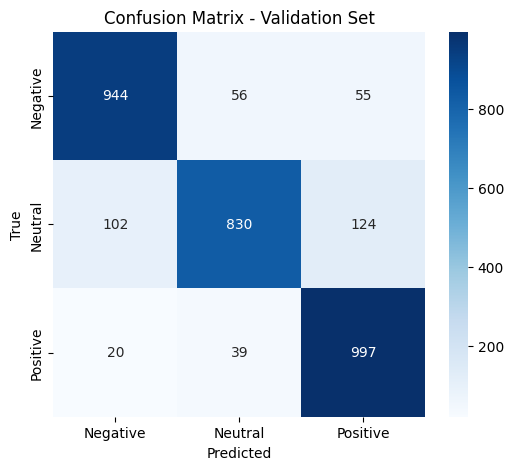


 Test Evaluation:


 Test Accuracy: 0.8873106060606061
 Test Report:
               precision    recall  f1-score   support

    Negative       0.90      0.89      0.90      1056
     Neutral       0.89      0.82      0.85      1056
    Positive       0.88      0.95      0.91      1056

    accuracy                           0.89      3168
   macro avg       0.89      0.89      0.89      3168
weighted avg       0.89      0.89      0.89      3168



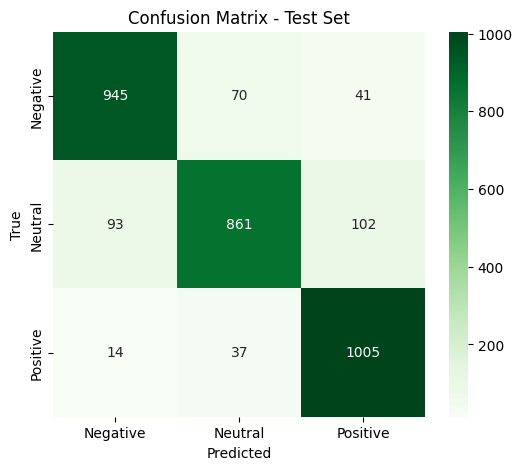

In [ ]:
# -----------------------
# 9. Evaluation (Validation)
# -----------------------
print("\n Validation Evaluation:")
val_preds = trainer.predict(val_dataset)
val_pred_labels = torch.argmax(torch.tensor(val_preds.predictions), axis=1)
val_true_labels = val_preds.label_ids

print(" Validation Accuracy:", accuracy_score(val_true_labels, val_pred_labels))
print(" Validation Report:\n", classification_report(val_true_labels, val_pred_labels, target_names=label_map.keys()))

val_conf_matrix = confusion_matrix(val_true_labels, val_pred_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(val_conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.title('Confusion Matrix - Validation Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# -----------------------
# 10. Evaluation (Test)
# -----------------------
print("\n Test Evaluation:")
test_preds = trainer.predict(test_dataset)
test_pred_labels = torch.argmax(torch.tensor(test_preds.predictions), axis=1)
test_true_labels = test_preds.label_ids

print(" Test Accuracy:", accuracy_score(test_true_labels, test_pred_labels))
print(" Test Report:\n", classification_report(test_true_labels, test_pred_labels, target_names=label_map.keys()))

test_conf_matrix = confusion_matrix(test_true_labels, test_pred_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(test_conf_matrix, annot=True, fmt="d", cmap="Greens", xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
# -----------------------
# 11. Inference on Custom Sentences
# -----------------------
from transformers import pipeline

# Reload the best model and tokenizer
sentiment_pipeline = pipeline(
    "text-classification",
    model="xlm-roberta-sentiment-best",
    tokenizer="xlm-roberta-sentiment-best",
    device=0 if torch.cuda.is_available() else -1
)

# Example Telugu sentences
example_sentences = [
    "ఈ సినిమా చాలా బాగుంది.",  # Positive
    "నాకు ఈ ప్రదర్శన నచ్చలేదు.",  # Negative
    "ఇది సరేలా ఉంది.",  # Neutral
    "వాతావరణం మంచిది కాదు.",  # Negative
    "ఆ వ్యక్తి మాట్లాడిన తీరు చాలా ఆహ్లాదకరంగా ఉంది."  # Positive
]

# Get predictions
predictions = sentiment_pipeline(example_sentences)

# Print results
print("\n💬 Example Predictions:")
for text, pred in zip(example_sentences, predictions):
    print(f"📝 Sentence: {text}")
    print(f"➡ Predicted Sentiment: {pred['label']} (Score: {pred['score']:.4f})\n")

Device set to use cuda:0



💬 Example Predictions:
📝 Sentence: ఈ సినిమా చాలా బాగుంది.
➡ Predicted Sentiment: Positive (Score: 0.9993)

📝 Sentence: నాకు ఈ ప్రదర్శన నచ్చలేదు.
➡ Predicted Sentiment: Negative (Score: 0.9978)

📝 Sentence: ఇది సరేలా ఉంది.
➡ Predicted Sentiment: Neutral (Score: 0.9806)

📝 Sentence: వాతావరణం మంచిది కాదు.
➡ Predicted Sentiment: Negative (Score: 0.9993)

📝 Sentence: ఆ వ్యక్తి మాట్లాడిన తీరు చాలా ఆహ్లాదకరంగా ఉంది.
➡ Predicted Sentiment: Positive (Score: 0.9983)



In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-sentiment-final")
tokenizer.save_pretrained("xlm-roberta-sentiment-final")


('xlm-roberta-sentiment-final/tokenizer_config.json',
 'xlm-roberta-sentiment-final/special_tokens_map.json',
 'xlm-roberta-sentiment-final/sentencepiece.bpe.model',
 'xlm-roberta-sentiment-final/added_tokens.json',
 'xlm-roberta-sentiment-final/tokenizer.json')